In [62]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [63]:
# 设置文件路径
train_path = '/Users/ggc/python learning/GGCHENINE/home-credit-default-risk/application_train.csv'
desc_path =  '/Users/ggc/python learning/GGCHENINE/home-credit-default-risk/HomeCredit_columns_description.csv'

In [64]:
# 读取数据
application_train = pd.read_csv(train_path)
columns_desc = pd.read_csv(desc_path,encoding="latin1")

In [65]:
application_train.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.000,406597.500,24700.500,...,0,0,0,0,0.000,0.000,0.000,0.000,0.000,1.000
1,100003,0,Cash loans,F,N,N,0,270000.000,1293502.500,35698.500,...,0,0,0,0,0.000,0.000,0.000,0.000,0.000,0.000
2,100004,0,Revolving loans,M,Y,Y,0,67500.000,135000.000,6750.000,...,0,0,0,0,0.000,0.000,0.000,0.000,0.000,0.000
3,100006,0,Cash loans,F,N,Y,0,135000.000,312682.500,29686.500,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.000,513000.000,21865.500,...,0,0,0,0,0.000,0.000,0.000,0.000,0.000,0.000


In [66]:
# 查看字段名
print(application_train.columns.tolist())
print("TARGET" in application_train.columns)
# 查看字段说明表
display(columns_desc.head(10))

['SK_ID_CURR', 'TARGET', 'NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE', 'NAME_TYPE_SUITE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'REGION_POPULATION_RELATIVE', 'DAYS_BIRTH', 'DAYS_EMPLOYED', 'DAYS_REGISTRATION', 'DAYS_ID_PUBLISH', 'OWN_CAR_AGE', 'FLAG_MOBIL', 'FLAG_EMP_PHONE', 'FLAG_WORK_PHONE', 'FLAG_CONT_MOBILE', 'FLAG_PHONE', 'FLAG_EMAIL', 'OCCUPATION_TYPE', 'CNT_FAM_MEMBERS', 'REGION_RATING_CLIENT', 'REGION_RATING_CLIENT_W_CITY', 'WEEKDAY_APPR_PROCESS_START', 'HOUR_APPR_PROCESS_START', 'REG_REGION_NOT_LIVE_REGION', 'REG_REGION_NOT_WORK_REGION', 'LIVE_REGION_NOT_WORK_REGION', 'REG_CITY_NOT_LIVE_CITY', 'REG_CITY_NOT_WORK_CITY', 'LIVE_CITY_NOT_WORK_CITY', 'ORGANIZATION_TYPE', 'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'APARTMENTS_AVG', 'BASEMENTAREA_AVG', 'YEARS_BEGINEXPLUATATION_AVG', 'YEARS_BUILD_AVG', 'COMMONAREA_AVG', 'ELE

,Unnamed: 0,Table,Row,Description,Special
0,1,application_{train|test}.csv,SK_ID_CURR,ID of loan in our sample,NaN
1,2,application_{train|test}.csv,TARGET,Target variable (1 - client with payment diffi...,NaN
2,5,application_{train|test}.csv,NAME_CONTRACT_TYPE,Identification if loan is cash or revolving,NaN
3,6,application_{train|test}.csv,CODE_GENDER,Gender of the client,NaN
4,7,application_{train|test}.csv,FLAG_OWN_CAR,Flag if the client owns a car,NaN
5,8,application_{train|test}.csv,FLAG_OWN_REALTY,Flag if client owns a house or flat,NaN
6,9,application_{train|test}.csv,CNT_CHILDREN,Number of children the client has,NaN
7,10,application_{train|test}.csv,AMT_INCOME_TOTAL,Income of the client,NaN
8,11,application_{train|test}.csv,AMT_CREDIT,Credit amount of the loan,NaN
9,12,application_{train|test}.csv,AMT_ANNUITY,Loan annuity,NaN


target将样本标记为0/1
target=1表示更高风险的违约相关标签
分为客户基本信息（年龄，性别，教育，婚姻状态等），表述客户画像与社会属性
收入，工作状态，职业，家庭成员数反映客户是否有稳定还款能力
贷款申请信息（金额，年金，产品类型）反映贷款本身结构
家庭结构，住房类型，居住地等判断客户稳定性
外部信用相关信息

In [67]:
# 查看整体数据类型情况
print("各数据类型字段数量")
print(application_train.dtypes.value_counts())

# 统计每列缺失值数量,比例，合并成一张表
missing_count = application_train.isnull().sum()
missing_pct = missing_count / len(application_train) 
missing_df = pd.DataFrame({
    "缺失值个数":missing_count,
    "缺失值比例":missing_pct
})
missing_df


各数据类型字段数量
float64    65
int64      41
str        16
Name: count, dtype: int64


,缺失值个数,缺失值比例
SK_ID_CURR,0,0.000
TARGET,0,0.000
NAME_CONTRACT_TYPE,0,0.000
CODE_GENDER,0,0.000
FLAG_OWN_CAR,0,0.000
...,...,...
AMT_REQ_CREDIT_BUREAU_DAY,41519,0.135
AMT_REQ_CREDIT_BUREAU_WEEK,41519,0.135
AMT_REQ_CREDIT_BUREAU_MON,41519,0.135
AMT_REQ_CREDIT_BUREAU_QRT,41519,0.135


In [68]:
# 筛选并排序
missing_df = missing_df[missing_df["缺失值个数"]>0].sort_values(
    by="缺失值比例",ascending=False
)
display(missing_df.head(20))
display(missing_df.tail(20))

,缺失值个数,缺失值比例
COMMONAREA_MEDI,214865,0.699
COMMONAREA_AVG,214865,0.699
COMMONAREA_MODE,214865,0.699
NONLIVINGAPARTMENTS_MEDI,213514,0.694
NONLIVINGAPARTMENTS_MODE,213514,0.694
NONLIVINGAPARTMENTS_AVG,213514,0.694
FONDKAPREMONT_MODE,210295,0.684
LIVINGAPARTMENTS_MODE,210199,0.684
LIVINGAPARTMENTS_MEDI,210199,0.684
LIVINGAPARTMENTS_AVG,210199,0.684


,缺失值个数,缺失值比例
TOTALAREA_MODE,148431,0.483
EMERGENCYSTATE_MODE,145755,0.474
OCCUPATION_TYPE,96391,0.313
EXT_SOURCE_3,60965,0.198
AMT_REQ_CREDIT_BUREAU_WEEK,41519,0.135
AMT_REQ_CREDIT_BUREAU_DAY,41519,0.135
AMT_REQ_CREDIT_BUREAU_MON,41519,0.135
AMT_REQ_CREDIT_BUREAU_QRT,41519,0.135
AMT_REQ_CREDIT_BUREAU_HOUR,41519,0.135
AMT_REQ_CREDIT_BUREAU_YEAR,41519,0.135


主表中部分房屋相关字段缺失比例很高，说明客户居住细节类信息覆盖有限，后续需要谨慎处理和解释

In [69]:
print("有缺失的字段数量：", missing_df.shape[0])


有缺失的字段数量： 67


In [70]:
# 查看数值型和类别型各自数量
numerical_cols = application_train.select_dtypes(include=["int64",'float64']).columns
categorical_cols = application_train.select_dtypes(include=["object","string"]).columns
print("数值型字段数量",len(numerical_cols),'\ntop10',numerical_cols[:10])
print("类别型字段数量",len(categorical_cols),'\ntop10',categorical_cols[:10])

数值型字段数量 106 
top10 Index(['SK_ID_CURR', 'TARGET', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL',
       'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE',
       'REGION_POPULATION_RELATIVE', 'DAYS_BIRTH', 'DAYS_EMPLOYED'],
      dtype='str')
类别型字段数量 16 
top10 Index(['NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY',
       'NAME_TYPE_SUITE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE',
       'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE'],
      dtype='str')


TARGET样本量 TARGET
0    282686
1     24825
Name: count, dtype: int64
TARGET
0   0.919
1   0.081
Name: proportion, dtype: float64


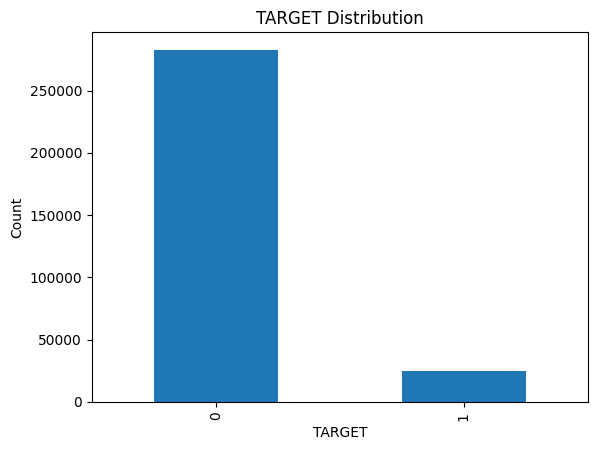

In [71]:
# 单变量分析（哪些特征和TARGET=1更相关，哪些客户可能属于高风险群体）
# 查看TARGET样本量
target_count = application_train["TARGET"].value_counts()
print("TARGET样本量",target_count)

# 查看TARGET样本比例
target_ratio = application_train["TARGET"].value_counts(normalize=True) 
# normalize=True 不返回“次数”，而返回“占比”
print(target_ratio)
print

target_count.plot(kind="bar")
plt.title("TARGET Distribution")
plt.xlabel("TARGET")
plt.ylabel("Count")
plt.show()

TARGET=0 样本明显多于 TARGET=1
TARGET=1 占比约为 8%，说明高风险样本在整体中属于少数类，数据存在一定的类别不平衡
这符合信贷风控场景中违约客户占比较低的业务特征
后续分析应重点比较高风险样本与正常样本在收入、贷款信息、家庭状况等特征上的差异，并更关注违约率而不只是样本数量

count      307511.000
mean       168797.919
std        237123.146
min         25650.000
25%        112500.000
50%        147150.000
75%        202500.000
max     117000000.000
Name: AMT_INCOME_TOTAL, dtype: float64

前十个收入值 
 0   202500.000
1   270000.000
2    67500.000
3   135000.000
4   121500.000
Name: AMT_INCOME_TOTAL, dtype: float64


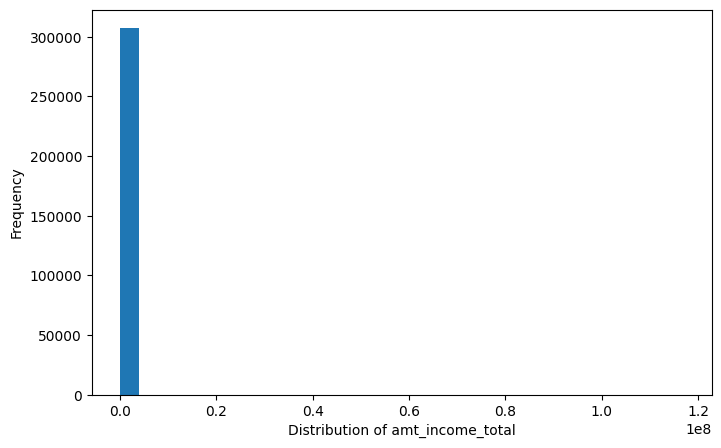

In [72]:
# 统计客户总收入，贷款等基本信息
pd.set_option("display.float_format", "{:.3f}".format)
print(application_train["AMT_INCOME_TOTAL"].describe())
print("\n前十个收入值",'\n',application_train["AMT_INCOME_TOTAL"].head())

# 绘制直方图
plt.figure(figsize=(8,5))
application_train['AMT_INCOME_TOTAL'].dropna().plot(kind='hist',bins=30)
plt.xlabel("Distribution of amt_income_total")
plt.ylabel("Frequency")
plt.show()

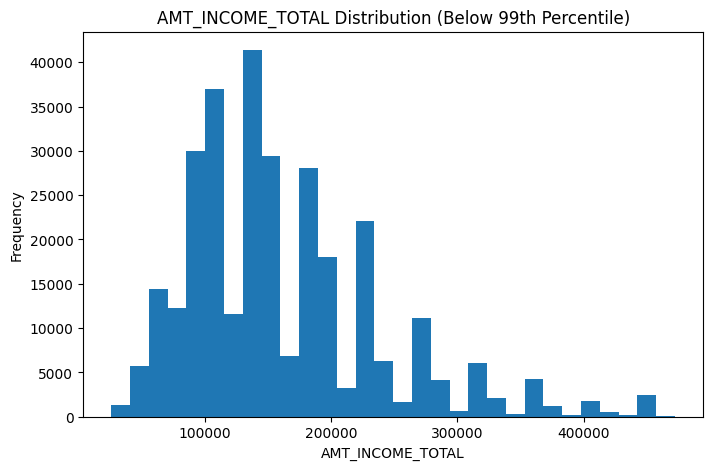

In [73]:
# 缩尾去除极端值的结果
income_cut = application_train["AMT_INCOME_TOTAL"][application_train["AMT_INCOME_TOTAL"]<=application_train["AMT_INCOME_TOTAL"].quantile(0.99)]
plt.figure(figsize=(8, 5))
income_cut.plot(kind="hist", bins=30)
plt.title("AMT_INCOME_TOTAL Distribution (Below 99th Percentile)")
plt.xlabel("AMT_INCOME_TOTAL")
plt.ylabel("Frequency")
plt.show()

AMT_INCOME_TOTAL 存在明显极端值，导致原始直方图的横轴被拉长，主流样本分布难以观察
在对极端值进行缩尾展示后，可以更清楚地看到大多数客户收入主要集中在 100000 - 200000 区间
说明该变量分布具有右偏特征，少数超高收入样本不代表整体客户结构，后续分析应更关注主流收入区间客户的风险差异

In [74]:
# 按照TARGET分组查看收入的描述性统计
income_by_target = application_train.groupby("TARGET")["AMT_INCOME_TOTAL"]
income_by_target.describe()


,count,mean,std,min,25%,50%,75%,max
TARGET,,,,,,,,
0,282686.000,169077.722,110476.269,25650.000,112500.000,148500.000,202500.000,18000090.000
1,24825.000,165611.761,746676.959,25650.000,112500.000,135000.000,202500.000,117000000.000


<Figure size 800x500 with 0 Axes>

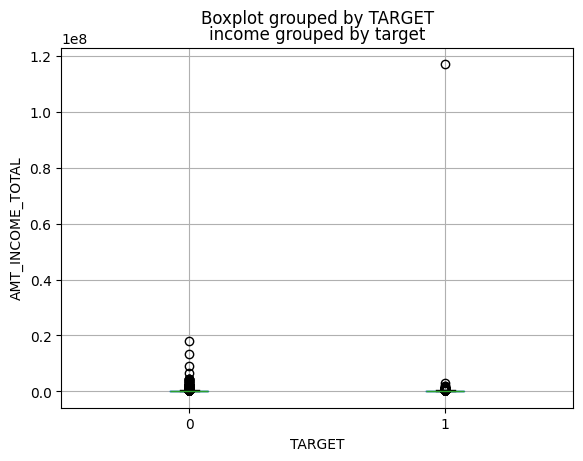

In [75]:
plt.figure(figsize=(8,5))
application_train.boxplot(column="AMT_INCOME_TOTAL",by="TARGET")
plt.title("income grouped by target")
plt.xlabel("TARGET")
plt.ylabel("AMT_INCOME_TOTAL")
plt.show()

# 在高风险客户中存在极端的，缩尾后查看正常客群收入分布

收入99%分位数： 472500.0
             mean     median
TARGET                      
0      163481.590 144000.000
1      157441.318 135000.000


<Figure size 800x500 with 0 Axes>

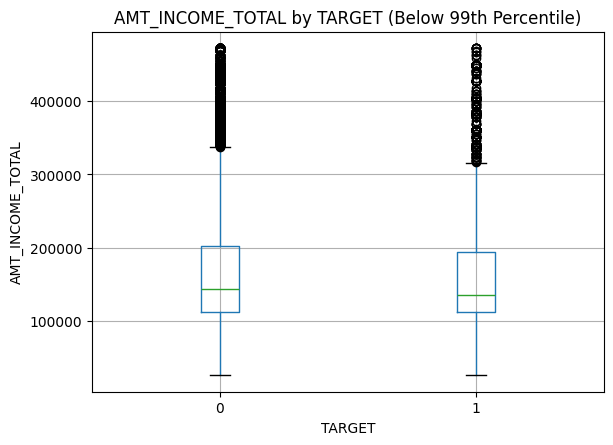

In [76]:
plt.figure(figsize=(8,5))
income_upper = application_train["AMT_INCOME_TOTAL"].quantile(0.99)
print("收入99%分位数：",income_upper)
income_filtered = application_train[application_train["AMT_INCOME_TOTAL"]<=income_upper]
income_compare_filtered = income_filtered.groupby("TARGET")["AMT_INCOME_TOTAL"].agg(['mean','median'])
print(income_compare_filtered)

income_filtered.boxplot(column="AMT_INCOME_TOTAL",by="TARGET")
plt.title("AMT_INCOME_TOTAL by TARGET (Below 99th Percentile)")
plt.suptitle("")
plt.xlabel("TARGET")
plt.ylabel("AMT_INCOME_TOTAL")
plt.show()

从箱线图来看，TARGET=0 和 TARGET=1 两组在 AMT_INCOME_TOTAL 上的分布较为接近，中位数和四分位区间差异不明显，说明收入水平对区分 TARGET 的作用可能有限。同时，两组都存在较多高收入异常值，表明该变量仍具有明显右偏特征。


In [77]:
# 单变量分析 贷款金额
display(application_train.head())
display(columns_desc.head(10))

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.000,406597.500,24700.500,...,0,0,0,0,0.000,0.000,0.000,0.000,0.000,1.000
1,100003,0,Cash loans,F,N,N,0,270000.000,1293502.500,35698.500,...,0,0,0,0,0.000,0.000,0.000,0.000,0.000,0.000
2,100004,0,Revolving loans,M,Y,Y,0,67500.000,135000.000,6750.000,...,0,0,0,0,0.000,0.000,0.000,0.000,0.000,0.000
3,100006,0,Cash loans,F,N,Y,0,135000.000,312682.500,29686.500,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.000,513000.000,21865.500,...,0,0,0,0,0.000,0.000,0.000,0.000,0.000,0.000


,Unnamed: 0,Table,Row,Description,Special
0,1,application_{train|test}.csv,SK_ID_CURR,ID of loan in our sample,NaN
1,2,application_{train|test}.csv,TARGET,Target variable (1 - client with payment diffi...,NaN
2,5,application_{train|test}.csv,NAME_CONTRACT_TYPE,Identification if loan is cash or revolving,NaN
3,6,application_{train|test}.csv,CODE_GENDER,Gender of the client,NaN
4,7,application_{train|test}.csv,FLAG_OWN_CAR,Flag if the client owns a car,NaN
5,8,application_{train|test}.csv,FLAG_OWN_REALTY,Flag if client owns a house or flat,NaN
6,9,application_{train|test}.csv,CNT_CHILDREN,Number of children the client has,NaN
7,10,application_{train|test}.csv,AMT_INCOME_TOTAL,Income of the client,NaN
8,11,application_{train|test}.csv,AMT_CREDIT,Credit amount of the loan,NaN
9,12,application_{train|test}.csv,AMT_ANNUITY,Loan annuity,NaN


In [78]:
print(application_train["AMT_CREDIT"].dtype,
      application_train["AMT_CREDIT"].isna().sum(),
      application_train["AMT_CREDIT"].shape[0])

float64 0 307511


In [79]:
# 描述性统计
amt_credit = application_train["AMT_CREDIT"]
amt_credit.describe()

count    307511.000
mean     599026.000
std      402490.777
min       45000.000
25%      270000.000
50%      513531.000
75%      808650.000
max     4050000.000
Name: AMT_CREDIT, dtype: float64

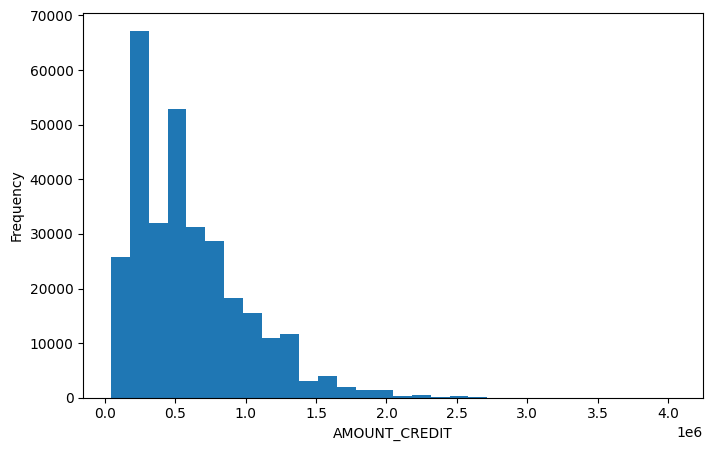

In [80]:
# 使用直方图查看分布状态
plt.figure(figsize=(8,5))
amt_credit.plot(kind='hist',bins=30)
plt.xlabel("AMOUNT_CREDIT")
plt.ylabel("Frequency")
plt.show()

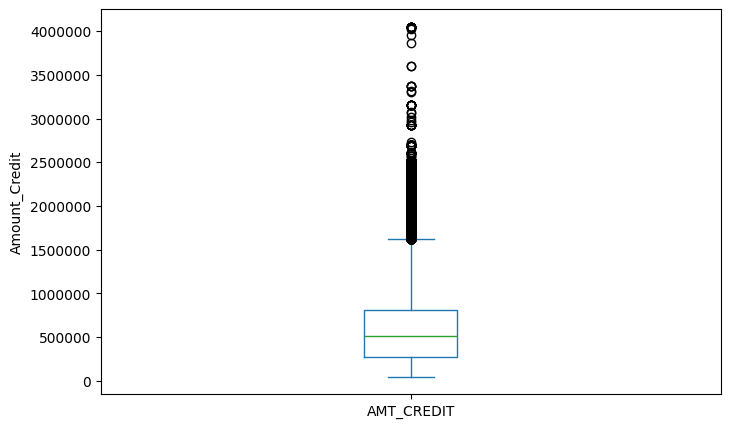

In [81]:
# 使用箱型图查看异常值
plt.figure(figsize=(8,5))
amt_credit.plot(kind="box")
plt.ylabel("Amount_Credit")
plt.ticklabel_format(style='plain', axis='y')
plt.show()

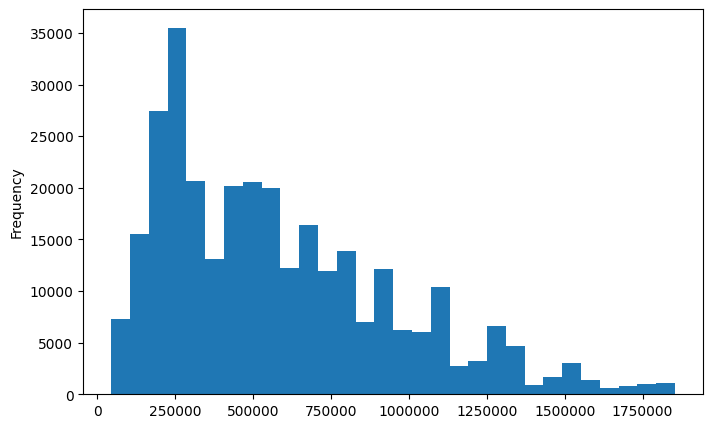

In [82]:
# 去除极端值后绘图
amt_credit_cut = application_train["AMT_CREDIT"][application_train["AMT_CREDIT"] <= application_train["AMT_CREDIT"].quantile(0.99)]
plt.figure(figsize=(8,5))
amt_credit_cut.plot(kind="hist",bins=30)
plt.ticklabel_format(style='plain', axis='x')

In [83]:
# 按照TARGET统计贷款
amt_credit_grp_by_target = application_train.groupby("TARGET")["AMT_CREDIT"]
amt_credit_grp_by_target.describe()

,count,mean,std,min,25%,50%,75%,max
TARGET,,,,,,,,
0,282686.000,602648.282,406845.908,45000.000,270000.000,517788.000,810000.000,4050000.000
1,24825.000,557778.528,346433.236,45000.000,284400.000,497520.000,733315.500,4027680.000


贷款99%分位数： 1854000.0
       SK_ID_CURR     TARGET  CNT_CHILDREN  AMT_INCOME_TOTAL  AMT_CREDIT  \
count  304436.000 304436.000    304436.000        304436.000  304436.000   
mean   278166.371      0.081         0.417        167097.392  583448.641   
std    102788.573      0.273         0.722        236755.065  372409.930   
min    100002.000      0.000         0.000         25650.000   45000.000   
25%    189119.750      0.000         0.000        112500.000  270000.000   
50%    278208.500      0.000         0.000        144000.000  508495.500   
75%    367103.250      0.000         1.000        202500.000  808650.000   
max    456255.000      1.000        19.000     117000000.000 1854000.000   

       AMT_ANNUITY  AMT_GOODS_PRICE  REGION_POPULATION_RELATIVE  DAYS_BIRTH  \
count   304424.000       304158.000                  304436.000  304436.000   
mean     26696.375       524027.664                       0.021  -16033.457   
std      13785.631       341254.277                       

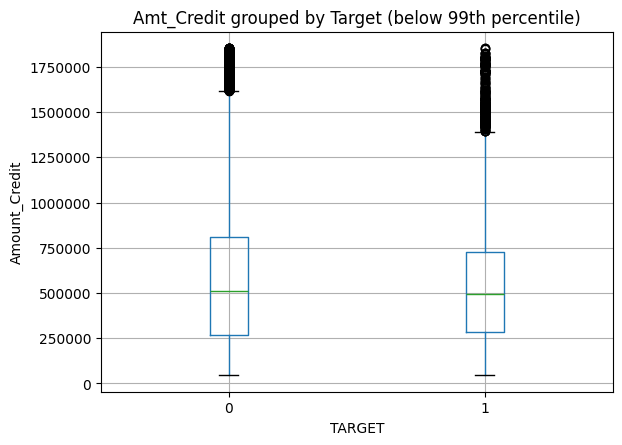

In [84]:
amt_credit_upper = application_train['AMT_CREDIT'].quantile(0.99)
print("贷款99%分位数：",amt_credit_upper)

amt_credit_filtered= application_train[application_train["AMT_CREDIT"] <= amt_credit_upper]
print(amt_credit_filtered.describe()) 

amt_credit_filtered.boxplot(column="AMT_CREDIT",by="TARGET")
plt.title("Amt_Credit grouped by Target (below 99th percentile)")
plt.suptitle("")
plt.xlabel("TARGET")
plt.ylabel("Amount_Credit")
plt.ticklabel_format(style='plain', axis='y')
plt.show()

关于统一阈值的说明

在比较 TARGET=0 和 TARGET=1 两组贷款金额差异时，主分析采用全体样本统一的 99% 分位数作为缩尾上界，而不是分别对两组使用各自的 99% 分位数。这样做的原因是：本步骤的重点是比较正常客户与高风险客户之间的差异，因此需要尽量保证两组使用相同的数据处理标准。若分别按组内分位数截尾，会导致两组保留的数据范围不同，从而影响组间结果的可比性。统一阈值更适合用于组间比较，而分组阈值更适合用于观察各组内部的主体分布。



关于贷款金额 AMT_CREDIT 的分析

AMT_CREDIT 为数值型变量，且无缺失值，说明该字段数据完整性较好，适合用于后续分析。根据描述性统计结果可知，贷款金额分布呈现明显右偏，最大值远高于中位数和 75% 分位数，说明存在较为明显的上尾极端值。原始分布中，贷款金额的 25% 分位数约为 270000，中位数约为 513531，75% 分位数约为 808650，说明主流贷款金额大致集中在几十万区间。

在使用全体样本统一 99% 分位数进行缩尾后，可以更清楚地观察主流贷款客户的分布情况，并减少极端值对图形和统计结果的干扰。进一步按 TARGET 分组比较发现，TARGET=1 组的贷款金额均值和中位数整体略低于 TARGET=0 组，说明在本数据中，高风险客户并不一定表现为“贷款金额更高”。这提示我们：违约风险未必单纯来自贷款规模本身，更可能与客户收入水平、还款负担、贷款金额与收入之间的匹配关系有关。

In [85]:
# 单变量分析 年金
print("AMT_ANNUITY 数据类型:",application_train['AMT_ANNUITY'].dtype,
      "\nAMT_ANNUITY 缺失值个数:",application_train['AMT_ANNUITY'].isna().sum(),
      "\nAMT_ANNUITY 样本总量:",application_train['AMT_ANNUITY'].shape[0])
amt_annuity = application_train['AMT_ANNUITY']
amt_annuity_counts = application_train['AMT_ANNUITY'].value_counts()
print("\n年金描述性统计\n",amt_annuity.describe())



AMT_ANNUITY 数据类型: float64 
AMT_ANNUITY 缺失值个数: 12 
AMT_ANNUITY 样本总量: 307511

年金描述性统计
 count   307499.000
mean     27108.574
std      14493.737
min       1615.500
25%      16524.000
50%      24903.000
75%      34596.000
max     258025.500
Name: AMT_ANNUITY, dtype: float64


分析均值和50%分位数可知，数据呈现右偏状态

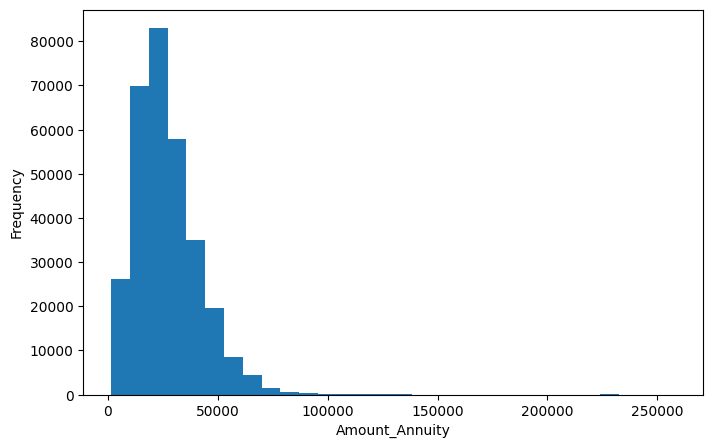

In [86]:
# 原始分布直方图
plt.figure(figsize=(8,5))
amt_annuity.dropna().plot(kind='hist',bins=30)
plt.xlabel("Amount_Annuity")
plt.ylabel("Frequency")
plt.show()

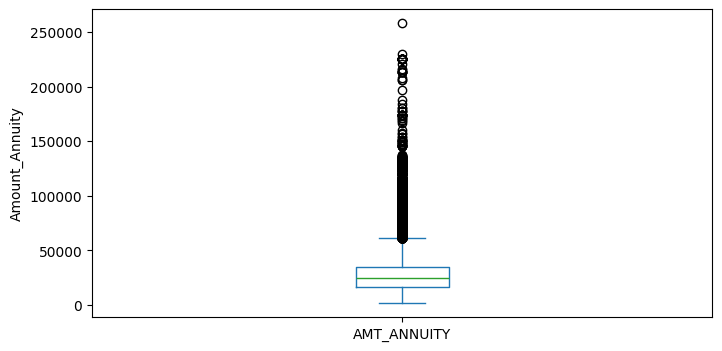

In [87]:
# 箱型图查看异常值
plt.figure(figsize=(8,4))
amt_annuity.dropna().plot(kind='box')
plt.ylabel("Amount_Annuity")
plt.show()

AMT_ANNUITY 的 99% 分位数： 70006.5


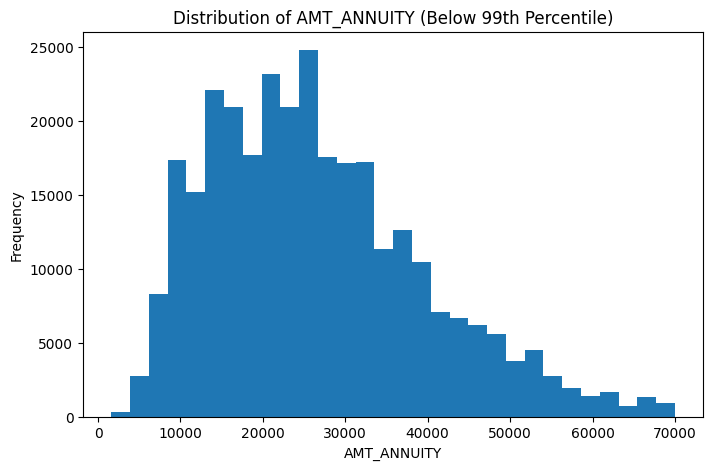


缩尾后按 TARGET 分组的 AMT_ANNUITY 描述性统计：
             count      mean       std      min       25%       50%       75%  \
TARGET                                                                         
0      279718.000 26524.400 13133.216 1615.500 16371.000 24714.000 34308.000   
1       24711.000 26226.162 11860.463 2722.500 17298.000 25191.000 32778.000   

             max  
TARGET            
0      70006.500  
1      70006.500  


<Axes: title={'center': 'AMT_ANNUITY'}, xlabel='TARGET'>

<Figure size 800x500 with 0 Axes>

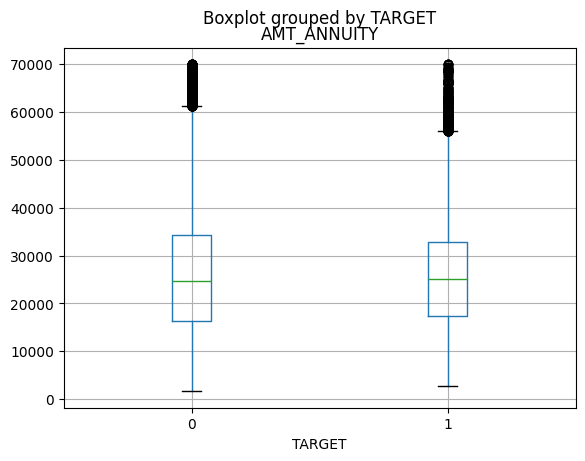

In [103]:
# 筛去极端值并分组
amt_annuity_upper = application_train["AMT_ANNUITY"].quantile(0.99)
print("AMT_ANNUITY 的 99% 分位数：", amt_annuity_upper)
# 使用统一 99% 分位数缩尾，观察主流分布
amt_annuity_filtered = application_train[application_train["AMT_ANNUITY"] <= amt_annuity_upper]
# 缩尾后直方图
plt.figure(figsize=(8,5))
amt_annuity_filtered["AMT_ANNUITY"].dropna().plot(kind="hist",bins=30)
plt.title("Distribution of AMT_ANNUITY (Below 99th Percentile)")
plt.xlabel("AMT_ANNUITY")
plt.ylabel("Frequency")
plt.show()
# 按 TARGET 分组，查看缩尾后的年金统计
amt_annuity_group_by_target = amt_annuity_filtered.groupby("TARGET")["AMT_ANNUITY"].describe()
print("\n缩尾后按 TARGET 分组的 AMT_ANNUITY 描述性统计：\n",amt_annuity_group_by_target)

# 缩尾后按TARGET画箱线图
plt.figure(figsize=(8,5))
amt_annuity_filtered.boxplot(column="AMT_ANNUITY",by="TARGET")




AMT_ANNUITY 为数值型变量，仅有少量缺失值，整体数据质量较好。根据描述性统计结果可知，该变量均值高于中位数，且最大值明显偏大，说明年金分布呈现右偏特征，并存在一定上尾极端值。为减少极端值对结果的影响，采用全体样本统一的 99% 分位数进行缩尾后，再比较 TARGET=0 与 TARGET=1 两组的分布情况。结果显示，两组在年金均值、中位数和四分位区间上的差异整体不大，说明单看年金绝对值，对区分高风险客户和正常客户的作用可能有限。从风控角度看，这意味着违约风险可能并不主要取决于“每期还款金额本身有多大”，而更可能与客户收入水平、贷款规模以及年金相对收入的负担程度有关。`

In [110]:
# 查看年金占收入比例,构造年金收入比
application_train["ANNUITY_INCOME_RATIO"] = (application_train["AMT_ANNUITY"] / application_train["AMT_INCOME_TOTAL"])

# 查看年金收入比基本情况
print("年金收入比缺失值：",application_train["ANNUITY_INCOME_RATIO"].isna().sum(),
      "\n年金收入比行数：",application_train['ANNUITY_INCOME_RATIO'].shape[0])
print("年金收入比描述性统计：")
print(application_train["ANNUITY_INCOME_RATIO"].describe())


年金收入比缺失值： 12 
年金收入比行数： 307511
年金收入比描述性统计：
count   307499.000
mean         0.181
std          0.095
min          0.000
25%          0.115
50%          0.163
75%          0.229
max          1.876
Name: ANNUITY_INCOME_RATIO, dtype: float64


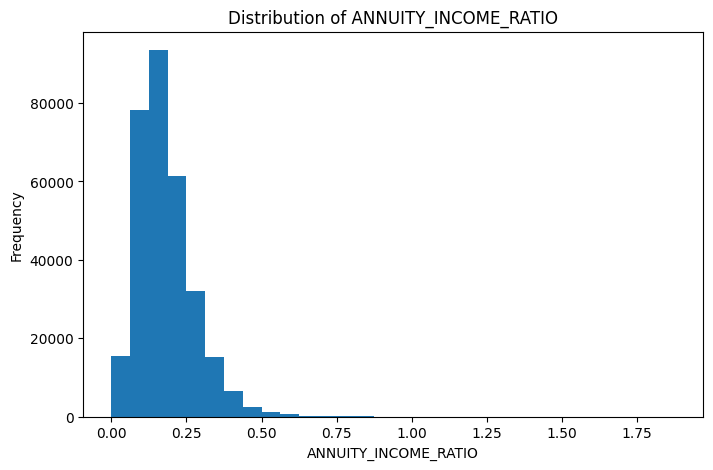

In [124]:
#查看原始分布 
plt.figure(figsize=(8,5))
application_train["ANNUITY_INCOME_RATIO"].dropna().plot(kind='hist',bins=30)
plt.title("Distribution of ANNUITY_INCOME_RATIO")
plt.xlabel("ANNUITY_INCOME_RATIO")
plt.ylabel("Frequency")
plt.show()

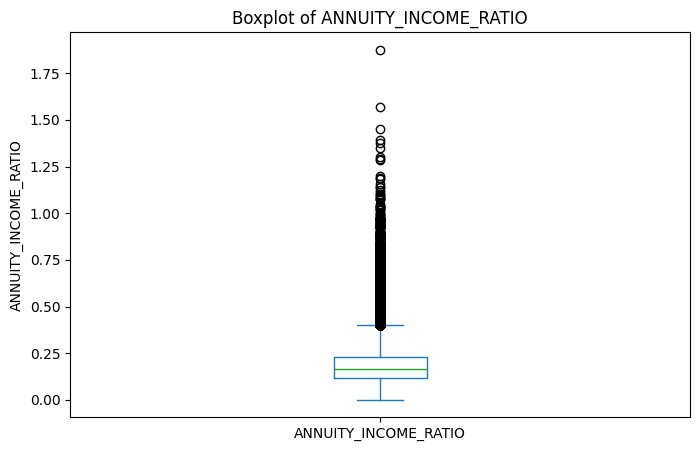

In [125]:
# 箱型图查看异常值
plt.figure(figsize=(8,5))
application_train["ANNUITY_INCOME_RATIO"].dropna().plot(kind='box')
plt.title("Boxplot of ANNUITY_INCOME_RATIO")
plt.ylabel("ANNUITY_INCOME_RATIO")
plt.show()


ANNUITY_INCOME_RATIO 的 99% 分位数： 0.4834584545454582

缩尾后按 TARGET 分组的 ANNUITY_INCOME_RATIO 描述性统计：
            count  mean   std   min   25%   50%   75%   max
TARGET                                                     
0      279833.000 0.176 0.085 0.003 0.114 0.161 0.226 0.483
1       24591.000 0.182 0.085 0.000 0.120 0.168 0.232 0.483

缩尾后按 TARGET 分组的 ANNUITY_INCOME_RATIO 均值和中位数：
        mean  median
TARGET              
0      0.176   0.161
1      0.182   0.168


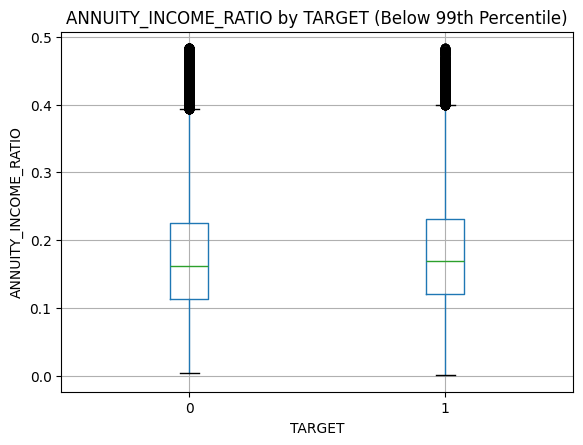

In [ ]:
# 使用统一 99% 分位数缩尾，便于比较 TARGET=0/1 两组
ratio_upper = application_train["ANNUITY_INCOME_RATIO"].quantile(0.99)
print("ANNUITY_INCOME_RATIO 的 99% 分位数：", ratio_upper)

# 过滤缺失值和上尾极端值
ratio_filtered = application_train[
    application_train["ANNUITY_INCOME_RATIO"].notna()
    & (application_train["ANNUITY_INCOME_RATIO"] <= ratio_upper)
]

# 按 TARGET 分组查看描述性统计
ratio_compare = ratio_filtered.groupby("TARGET")["ANNUITY_INCOME_RATIO"].describe()
print("\n缩尾后按 TARGET 分组的 ANNUITY_INCOME_RATIO 描述性统计：")
print(ratio_compare)

# 单独查看均值和中位数
ratio_mean_median = ratio_filtered.groupby("TARGET")["ANNUITY_INCOME_RATIO"].agg(["mean", "median"])
print("\n缩尾后按 TARGET 分组的 ANNUITY_INCOME_RATIO 均值和中位数：")
print(ratio_mean_median)

# 缩尾后箱线图
ratio_filtered.boxplot(column="ANNUITY_INCOME_RATIO", by="TARGET")
plt.title("ANNUITY_INCOME_RATIO by TARGET (Below 99th Percentile)")
plt.suptitle("")
plt.xlabel("TARGET")
plt.ylabel("ANNUITY_INCOME_RATIO")
plt.show()


ANNUITY_INCOME_RATIO 反映客户每期还款金额占收入的比例，是衡量偿债压力的重要指标。描述性统计和图形结果显示，该变量整体右偏，说明少数客户存在较高的还款负担。使用统一 99% 分位数缩尾后比较 TARGET=0/1 两组发现，高风险组的年金收入比整体更高，说明还款负担相对收入越重，客户发生违约的可能性可能越大。这表明，相比单独考察年金或贷款金额，年金收入比更能体现风控中的真实压力。`

In [126]:
# 分组违约率分析
ratio_df = application_train[["ANNUITY_INCOME_RATIO",'TARGET']].dropna().copy()

# 按照分位数分为5组
ratio_df["RATIO_BIN"] = pd.qcut(
    ratio_df["ANNUITY_INCOME_RATIO"],
    q=5,
    duplicates='drop'
)

# 分组统计各组样本量与违约率
ratio_risk = ratio_df.groupby("RATIO_BIN")['TARGET'].agg(['count','mean'])
ratio_risk = ratio_risk.rename(columns={
                               'count':"样本量",
                               "mean":"违约率"})
print(ratio_risk)

                      样本量   违约率
RATIO_BIN                      
(-0.000776, 0.104]  61500 0.072
(0.104, 0.144]      61507 0.078
(0.144, 0.186]      61494 0.081
(0.186, 0.247]      61522 0.087
(0.247, 1.876]      61476 0.085


/opt/anaconda3/envs/pydata-book/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 20998 (\N{CJK UNIFIED IDEOGRAPH-5206}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/envs/pydata-book/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 32452 (\N{CJK UNIFIED IDEOGRAPH-7EC4}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


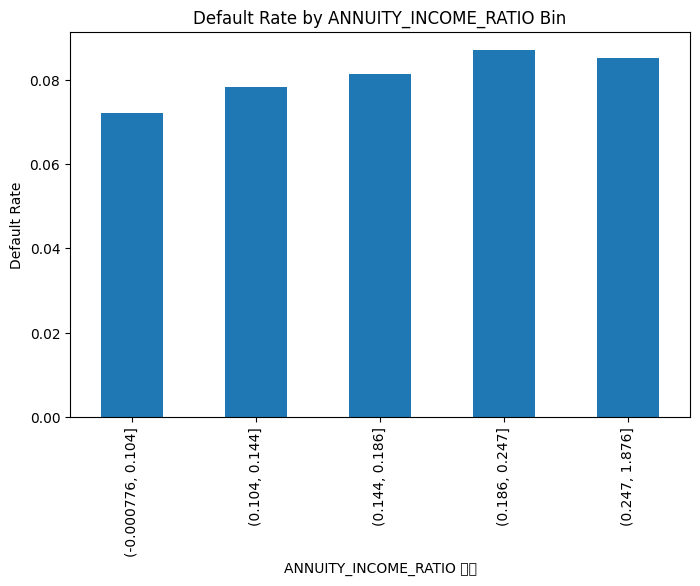

In [127]:
plt.figure(figsize=(8,5))
ratio_risk['违约率'].plot(kind='bar')
plt.title("Default Rate by ANNUITY_INCOME_RATIO Bin")
plt.xlabel("ANNUITY_INCOME_RATIO 分组")
plt.ylabel("Default Rate")
plt.show()

将 ANNUITY_INCOME_RATIO 按分位数分组后发现，各组样本量较为均衡，违约率整体随年金收入比上升而增大，说明客户还款负担相对收入越重，其违约风险越高。虽然最高组违约率略有回落，但总体趋势仍较清晰。最高风险组较最低风险组违约率高约 0.015，表明年金收入比具有一定的风险区分能力。

In [131]:
#对总收入做分组违约率分析
income_df = application_train[["AMT_INCOME_TOTAL","TARGET"]].dropna().copy()

# 按照分位数分为5组
display(income_df.head())
income_df['INCOME_BIN'] = pd.qcut(
    income_df["AMT_INCOME_TOTAL"],
    q=5,
    duplicates='drop'
)

# 分组统计各组样本量与违约率
income_risk = income_df.groupby("INCOME_BIN")['TARGET'].agg(['count','mean'])
income_risk = income_risk.rename(columns=
                                 {
                                     "count":'样本量',
                                     'mean':"违约率"
                                 })

print(income_risk)

,AMT_INCOME_TOTAL,TARGET
0,202500.000,1
1,270000.000,0
2,67500.000,0
3,135000.000,0
4,121500.000,0


                           样本量   违约率
INCOME_BIN                          
(25649.999, 99000.0]     63671 0.082
(99000.0, 135000.0]      85756 0.086
(135000.0, 162000.0]     35453 0.087
(162000.0, 225000.0]     75513 0.081
(225000.0, 117000000.0]  47118 0.065


/opt/anaconda3/envs/pydata-book/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 20998 (\N{CJK UNIFIED IDEOGRAPH-5206}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/envs/pydata-book/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 32452 (\N{CJK UNIFIED IDEOGRAPH-7EC4}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


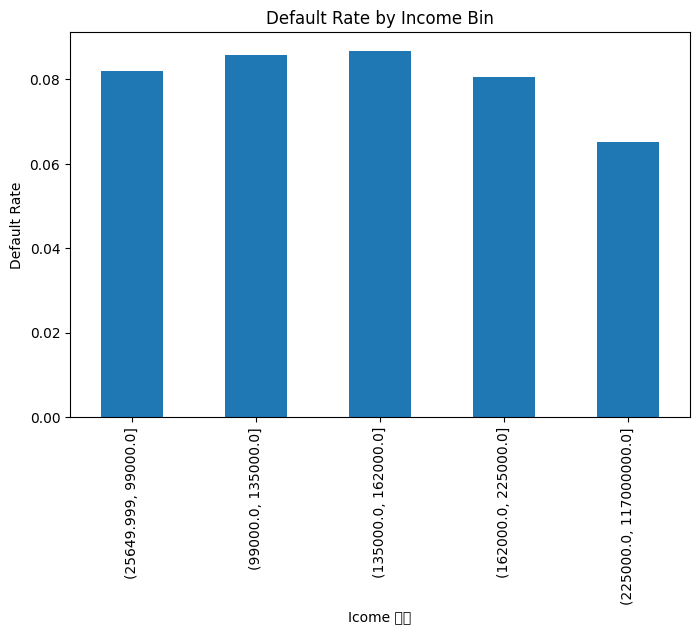

In [130]:
plt.figure(figsize=(8,5))
income_risk['违约率'].plot(kind='bar')
plt.title("Default Rate by Income Bin")
plt.xlabel("Icome 分组")
plt.ylabel("Default Rate")
plt.show()

将 AMT_INCOME_TOTAL 按分位数分组后发现，收入与违约风险存在一定关系，但趋势并非完全单调。最高收入组违约率明显较低，说明高收入客户整体风险更低；而中低收入组违约率相对更高，表明收入水平对风险具有一定解释力。不过，相比年金收入比，收入这一单一变量的区分能力相对有限。
收入、年金和年金收入比对违约风险的解释力度存在差异。收入水平能够在一定程度上反映客户风险，高收入组整体违约率更低；年金绝对值的区分能力相对有限；而年金收入比的风险趋势最为清晰，说明还款负担相对收入越重，客户风险越高。因此，从风控角度看，年金收入比比单独的收入或年金更能反映客户的实际偿债压力。

In [133]:
# 对收入类型进行分析
income_type_risk = application_train.groupby('NAME_INCOME_TYPE')['TARGET'].agg(['count','mean'])
income_type_risk = income_type_risk.rename(columns={
    "count": "样本量",
    "mean": "违约率"
})
income_type_risk

,样本量,违约率
NAME_INCOME_TYPE,,
Businessman,10,0.000
Commercial associate,71617,0.075
Maternity leave,5,0.400
Pensioner,55362,0.054
State servant,21703,0.058
Student,18,0.000
Unemployed,22,0.364
Working,158774,0.096


                         样本量   违约率
NAME_INCOME_TYPE                  
Maternity leave            5 0.400
Unemployed                22 0.364
Working               158774 0.096
Commercial associate   71617 0.075
State servant          21703 0.058
Pensioner              55362 0.054
Businessman               10 0.000
Student                   18 0.000


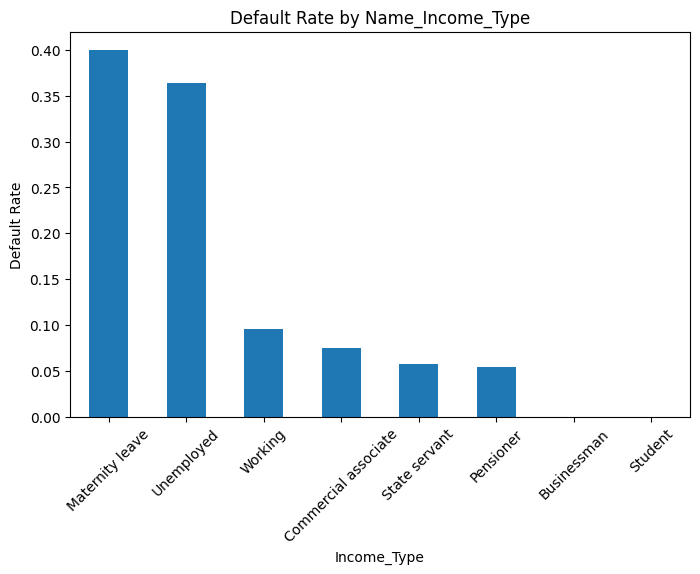

In [135]:
income_type_risk = income_type_risk.sort_values(by='违约率',ascending=False)
print(income_type_risk)

# 绘图查看不同收入类型的违约率
plt.figure(figsize=(8,5))
income_type_risk['违约率'].plot(kind='bar')
plt.title("Default Rate by Name_Income_Type")
plt.xlabel("Income_Type")
plt.ylabel('Default Rate')
plt.xticks(rotation=45)
plt.show()

对 NAME_INCOME_TYPE 的分组分析显示，收入来源类型与违约风险存在差异。Maternity leave和Unemployed 的违约率较高，但样本量较少，因此只能作为高风险提示；Businessman和Student 虽然违约率为 0，但同样由于样本量有限，结论不具备足够稳定性。这说明类别变量分析中，违约率必须结合样本量共同解释

In [139]:
# 对教育程度进行分析
edu_type_risk = application_train.groupby('NAME_EDUCATION_TYPE')['TARGET'].agg(['mean','count'])
edu_type_risk = edu_type_risk.rename(columns={
    'count':'样本量',
    'mean':'违约率'
})
edu_type_risk

,违约率,样本量
NAME_EDUCATION_TYPE,,
Academic degree,0.018,164
Higher education,0.054,74863
Incomplete higher,0.085,10277
Lower secondary,0.109,3816
Secondary / secondary special,0.089,218391


                                违约率     样本量
NAME_EDUCATION_TYPE                        
Lower secondary               0.109    3816
Secondary / secondary special 0.089  218391
Incomplete higher             0.085   10277
Higher education              0.054   74863
Academic degree               0.018     164


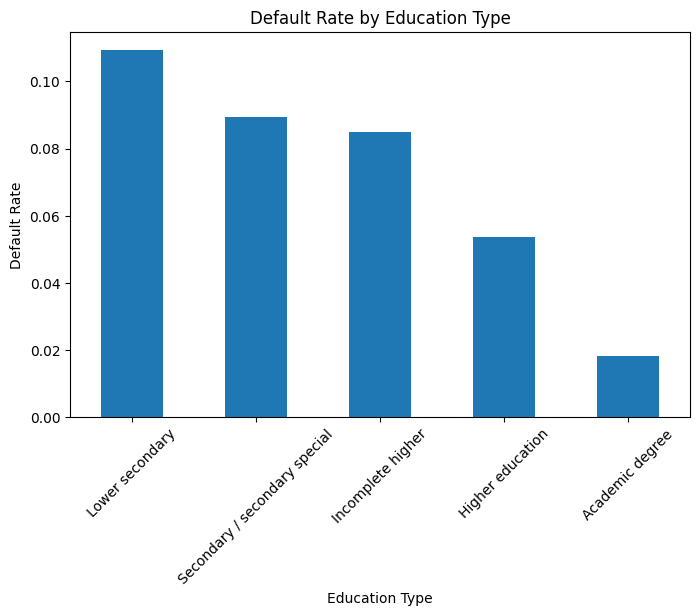

In [143]:
# 排序
edu_type_risk = edu_type_risk.sort_values(by='违约率',ascending=False)
print(edu_type_risk)

# 绘图查看不同教育程度低违约率
plt.figure(figsize=(8,5))
edu_type_risk['违约率'].plot(kind='bar')
plt.title("Default Rate by Education Type")
plt.xlabel("Education Type")
plt.ylabel("Default Rate")
plt.xticks(rotation=45)
plt.show()

教育程度分组结果显示，客户违约率整体随教育程度提升而下降。Higher education的违约率明显低于Secondary / secondary special和Lower secondary，说明教育程度较高的客户整体风险更低。不过，Academic degree 样本量较小，极低违约率的稳定性有限，因此更应关注整体趋势而不是小样本极端值。



类别变量分析结果表明，客户收入来源类型和教育程度都与违约风险存在一定关系。NAME_INCOME_TYPE 中，收入来源不稳定或处于特殊状态的客户违约率相对更高，但部分高风险类别样本量较小，因此需谨慎解释。NAME_EDUCATION_TYPE 显示教育程度越高，客户整体违约率越低，说明教育背景在一定程度上能够反映客户的稳定性和偿债能力。总体来看，类别变量分析为识别不同风险客群提供了较好的业务解释。

综合当前分析结果，高风险客户的初步特征可以概括为：还款负担相对收入更重、收入能力相对较弱、教育程度较低，以及收入来源稳定性可能不足。其中，年金收入比表现出较清晰的风险上升趋势，是目前最有解释力的指标之一。相比之下，收入和教育程度也能提供一定风险线索，但更适合作为辅助判断；而部分收入来源类型虽然违约率较高，但由于样本量较小，需谨慎解释

截至目前，本项目已完成数据读取、字段理解、缺失值分析、关键数值变量分析和部分分组违约率分析。结果显示，违约客户在总体中占比较低，数据存在类别不平衡；部分房屋类字段缺失较高，需要谨慎解释。金额类变量普遍存在右偏和极端值，其中收入和年金的风险区分能力有限，而年金收入比能够更清晰地反映客户还款负担与违约风险之间的关系。类别变量分析进一步表明，收入来源类型和教育程度与违约风险存在一定关联。综合来看，高风险客户更可能表现为收入能力较弱、教育程度较低、收入来源稳定性不足，以及还款负担相对收入较重。

In [166]:
# 家庭结构与婚姻状态字段检查
print("NAME_FAMILY_STATUS 是否存在：", "NAME_FAMILY_STATUS" in application_train.columns)
print("\n各家庭状态样本量：")
print(application_train["NAME_FAMILY_STATUS"].value_counts())


NAME_FAMILY_STATUS 是否存在： True

各家庭状态样本量：
NAME_FAMILY_STATUS
Married                 196432
Single / not married     45444
Civil marriage           29775
Separated                19770
Widow                    16088
Unknown                      2
Name: count, dtype: int64


In [168]:
# 统计家庭状态的样本量和违约率
family_status_risk = application_train.groupby("NAME_FAMILY_STATUS")["TARGET"].agg(["count", "mean"])
family_status_risk = family_status_risk.rename(columns={
    "count": "样本量",
    "mean": "违约率"
})
family_status_risk = family_status_risk[["样本量", "违约率"]].sort_values(by="违约率", ascending=False)

print("家庭状况信息：")
print(family_status_risk)

print("\n样本量较小的类别：")
print(family_status_risk[family_status_risk["样本量"] < 100])


家庭状况信息：
                         样本量   违约率
NAME_FAMILY_STATUS                
Civil marriage         29775 0.099
Single / not married   45444 0.098
Separated              19770 0.082
Married               196432 0.076
Widow                  16088 0.058
Unknown                    2 0.000

样本量较小的类别：
                    样本量   违约率
NAME_FAMILY_STATUS           
Unknown               2 0.000


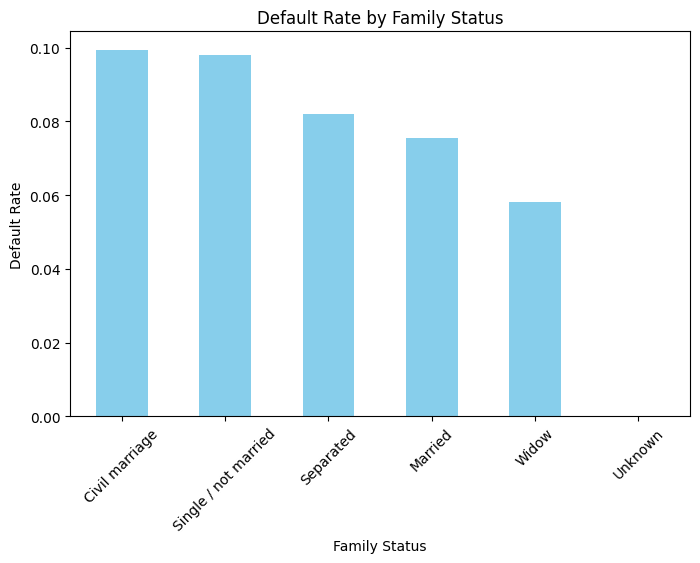

In [173]:
# 仅绘制违约率，避免与样本量混在一张图里
ax = family_status_risk["违约率"].plot(kind="bar", figsize=(8, 5),color='skyblue')
ax.set_title("Default Rate by Family Status")
ax.set_xlabel("Family Status")
ax.set_ylabel("Default Rate")
plt.xticks(rotation=45)
plt.show()


家庭状态分组结果显示，Civil marriage和Single / not married 的违约率相对较高，Married和Widow 的违约率相对较低，说明家庭结构与客户风险存在一定关系。需要注意的是，Unknown 类别样本量极小，不能过度解释。总体上看，家庭状态可以作为辅助理解客户稳定性和风险差异的一个变量。

截至目前，本项目已完成数据读取、字段理解、缺失值分析、关键数值变量分析和部分分组违约率分析。结果表明，违约客户在总体中占比较低，数据存在一定类别不平衡；部分房屋类字段缺失较高，需要谨慎解释。数值变量中，年金收入比比单独的收入、贷款金额和年金更能体现客户的真实偿债压力；类别变量中，收入来源类型、教育程度和家庭状态都与违约风险存在一定关系。综合来看，高风险客户更可能表现为收入能力较弱、教育程度较低、收入来源稳定性不足，以及还款负担相对收入较重。

In [175]:
# 对住房类型进行分组违约率分析
housing_type_risk = application_train.groupby("NAME_HOUSING_TYPE")['TARGET'].agg({"mean","count"})
housing_type_risk = housing_type_risk.rename(columns={
    'count':"样本量",
    'mean':'违约率'
})

housing_type_risk = housing_type_risk.sort_values(by='违约率',ascending=False)
print('住房类型信息：')
print(housing_type_risk)



住房类型信息：
                        样本量   违约率
NAME_HOUSING_TYPE                
Rented apartment       4881 0.123
With parents          14840 0.117
Municipal apartment   11183 0.085
Co-op apartment        1122 0.079
House / apartment    272868 0.078
Office apartment       2617 0.066


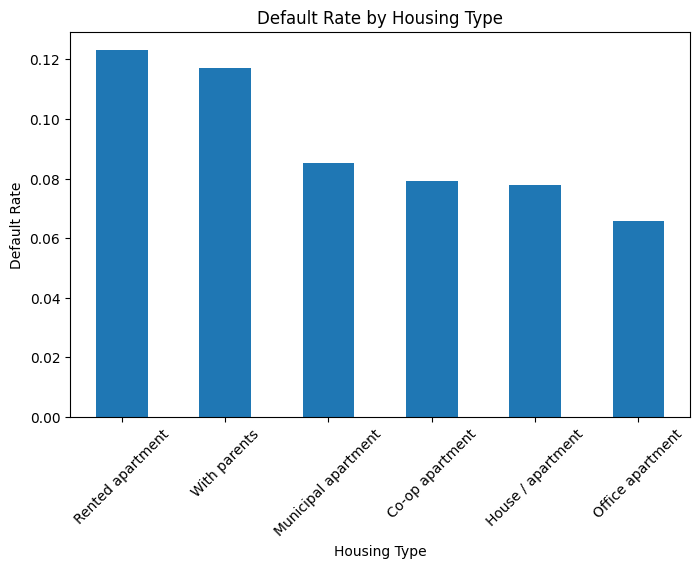

In [176]:
# 违约率图
ax = housing_type_risk['违约率'].plot(kind='bar',figsize=(8,5))
ax.set_title("Default Rate by Housing Type")
ax.set_xlabel("Housing Type")
ax.set_ylabel("Default Rate")
plt.xticks(rotation=45)
plt.show()